## Imports

In [442]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler
from pykalman import KalmanFilter
import hmmlearn.hmm as hmm
from hmmlearn.hmm import GaussianHMM
import random
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings 

warnings.filterwarnings("ignore")




## Get asset candle data

In [443]:

asset = "bitcoin"

# Load asset data
df_1 = pd.read_csv(f"micro/candleData/{asset}_candles.csv")
df_1['date'] = pd.to_datetime(df_1['date'])
df_1.set_index('date', inplace=True)

df_2 = pd.read_csv(f"micro/assetData/{asset}.csv")
df_2['date'] = pd.to_datetime(df_2['date'])
df_2.set_index('date', inplace=True)

data = pd.merge(df_1, df_2[['total_volume']], left_index=True, right_index=True, how='inner')

data.rename(columns={'total_volume': 'Volume',
                     'open': 'Open',
                     'high': 'High',
                     'low': 'Low',
                     'close': 'Close'}, inplace=True)



# Print final data quality check
print("\nFinal Dataset Shape:", data.shape)
print("\nMissing Values in Final Dataset:")
print(data.isnull().sum())

# Convert daily candle data to weekly candle data.
# Make sure your index is a DateTimeIndex with the index name 'Date'
# Convert daily candle data to weekly candle data.
weekly_data = data.resample('W').agg({
    'Open': 'first',
    'High': 'max',
    'Low': 'min',
    'Close': 'last',
    'Volume': 'sum'
}).dropna()

# Reset the index and rename the datetime column to "Date"
weekly_data = weekly_data.reset_index()
# If the date column is named 'date', rename it:
if 'date' in weekly_data.columns:
    weekly_data.rename(columns={'date': 'Date'}, inplace=True)

# Use weekly_data for the rest of your pipeline.
data = weekly_data.copy()

# (Do NOT call df.reset_index(inplace=True) later if you already have the "Date" column.)

data.index.name = 'Date'

data


Final Dataset Shape: (4313, 5)

Missing Values in Final Dataset:
Open      2
High      2
Low       2
Close     2
Volume    0
dtype: int64


,Date,Open,High,Low,Close,Volume
Date,,,,,,
0,2013-05-05,135.30,141.96,91.01,111.25,0.000000e+00
1,2013-05-12,116.79,118.78,106.40,113.01,0.000000e+00
2,2013-05-19,114.71,123.88,114.16,123.88,0.000000e+00
3,2013-05-26,120.50,131.70,120.50,130.77,0.000000e+00
4,2013-06-02,134.60,134.60,127.40,129.09,0.000000e+00
...,...,...,...,...,...,...
612,2025-01-26,101184.00,108786.00,99702.00,102552.00,4.677881e+11
613,2025-02-02,102625.00,106191.00,96453.00,97568.00,3.483200e+11
614,2025-02-09,97652.00,102614.00,92460.00,96558.00,3.919675e+11


## Calculate features

#### Plot feature distributions

In [444]:
def plot_feature_distributions(df, feature_cols=None, bins=50, figsize=(15, 10)):
    """
    Plots the distribution (histograms) of specified feature columns in a DataFrame.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing your features.
    feature_cols : list of str, optional
        List of columns to plot. If None, attempts to plot all numeric columns 
        except non-feature columns (e.g., 'symbol', 'interval', 'Date').
    bins : int, optional
        Number of histogram bins. Default 50.
    figsize : tuple, optional
        Figure size for the overall plot. Default (15, 10).
    
    Returns
    -------
    None (Displays a Matplotlib figure of histograms)
    """
    
    # If user does not specify feature columns, attempt to infer from numeric columns
    if feature_cols is None:
        # Exclude any known non-feature columns
        exclude_cols = {'symbol', 'interval', 'Date'}
        feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                        if col not in exclude_cols]
    
    n_features = len(feature_cols)
    
    # Decide on subplot grid (approx square layout)
    n_cols = int(np.ceil(np.sqrt(n_features)))
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten to easily iterate even if there's only 1 row
    
    for i, col in enumerate(feature_cols):
        ax = axes[i]
        # Drop NaN to avoid issues in hist
        valid_data = df[col].dropna()
        ax.hist(valid_data, bins=bins, edgecolor='k', alpha=0.7)
        ax.set_title(col)
        ax.set_ylabel('Count')
        ax.set_xlabel('Value')
        ax.grid(True, linestyle='--', alpha=0.5)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

#### Generate and normalize features

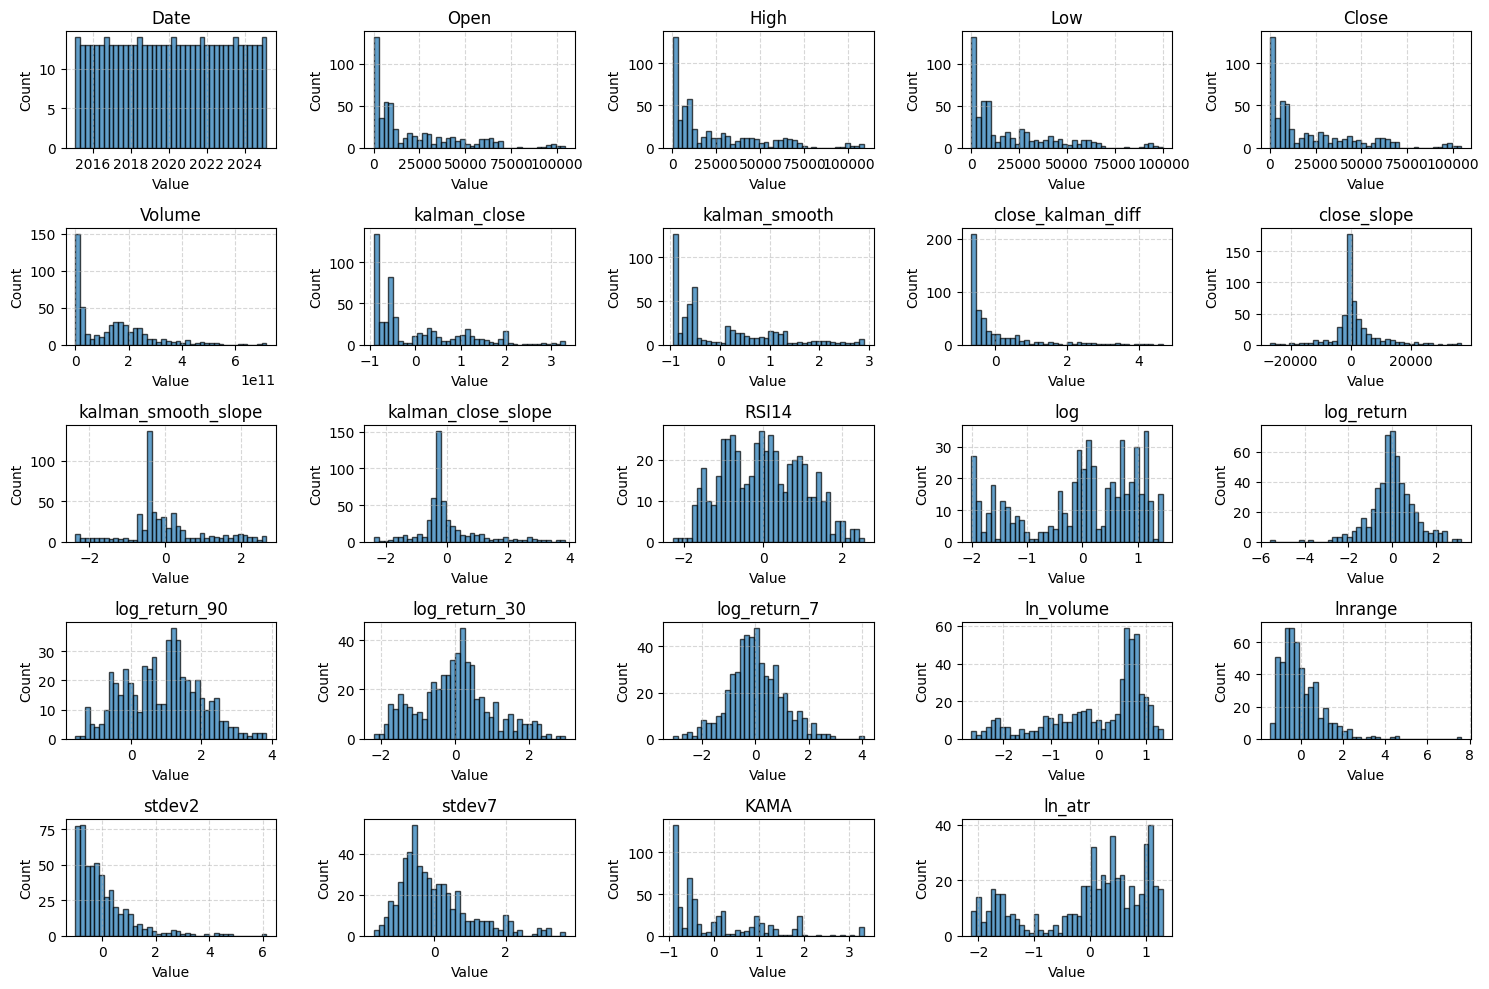

In [445]:

def kama(series, n=10, fast=2, slow=30):
    """
    Calculate the Kaufman Adaptive Moving Average (KAMA) for a given price series.

    Parameters:
    -----------
    series : pd.Series
        Price series (e.g., Close prices).
    n : int, optional
        Number of periods to use for the efficiency ratio. Default is 10.
    fast : int, optional
        The period for the fastest allowable EMA. Default is 2.
    slow : int, optional
        The period for the slowest allowable EMA. Default is 30.

    Returns:
    --------
    pd.Series
        A Series containing the computed KAMA values.
    """

    # Calculate the Efficiency Ratio (ER)
    change = series.diff(n).abs()
    volatility = series.diff().abs().rolling(n).sum()
    er = change / volatility
    er = er.fillna(0)

    # Calculate the smoothing constant (SC)
    fast_sc = 2 / (fast + 1)
    slow_sc = 2 / (slow + 1)
    sc = (er * (fast_sc - slow_sc) + slow_sc) ** 2

    # Allocate an array for KAMA values and initialize with NaNs.
    kama_values = pd.Series(np.nan, index=series.index)
    # Set the first valid KAMA value equal to the price at the n-th index.
    if len(series) > n:
        kama_values.iloc[n] = series.iloc[n]
    
    # Recursively compute KAMA starting from the (n+1)-th element.
    for i in range(n + 1, len(series)):
        kama_values.iloc[i] = kama_values.iloc[i - 1] + sc.iloc[i] * (series.iloc[i] - kama_values.iloc[i - 1])
    
    return kama_values

def calculate_atr(high, low, close, window=14):
    """
    Calculate the Average True Range (ATR).

    ATR is defined as the rolling average (window=14 by default) of the True Range.
    True Range (TR) is the maximum of:
      - (High - Low)
      - Absolute(High - previous Close)
      - Absolute(Low - previous Close)
    """
    prev_close = close.shift(1)
    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(window=window, min_periods=window).mean()
    return atr

# Setup Kalman Filter (make sure data is loaded before setting initial_state_mean)
kf = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=None,  # will be set after loading data
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.01
)

# Assume 'data' has already been loaded and merged with macro data.
df = data.copy()
df.dropna(inplace=True)

# Apply the Kalman filter on Close prices
kf.initial_state_mean = df['Close'].iloc[0]
state_means, state_covariances = kf.filter(df['Close'].values)
df['kalman_close'] = state_means.flatten()
smoothed_state_means, smoothed_state_covariances = kf.smooth(df['kalman_close'].values)
df['kalman_smooth'] = smoothed_state_means.flatten()
df['close_kalman_diff'] = np.abs(df['Close'] - df['kalman_smooth'])
df['close_slope'] = df['Close'].diff(periods=7)
df['kalman_smooth_slope'] = df['kalman_smooth'].diff(periods=7)
df['kalman_close_slope'] = df['kalman_close'].diff(periods=7)
# Compute technical indicators
df['RSI14'] = ta.rsi(df['Close'], length=14)

# Handle potential infinities in log calculations
df['log'] = np.log(df['Close'].replace(0, np.nan))
df['log_return'] = df['log'].diff()
df['log_return_90'] = df['log'].diff(periods=90)
df['log_return_30'] = df['log'].diff(periods=30)
df['log_return_7'] = df['log'].diff(periods=7)
df['ln_volume'] = np.log(df['Volume'].replace(0, np.nan) + 1)  # Add 1 to avoid log(0)
df['lnrange'] = np.log((df['High'] / df['Low']).replace([np.inf, -np.inf], np.nan))
df['stdev2'] = df['log_return'].rolling(window=2).std()
df['stdev7'] = df['log_return'].rolling(window=7).std()
# Calculate ATR and handle potential infinities
df['KAMA'] = kama(df['Close'], n=10, fast=2, slow=30)
df['ln_atr'] = np.log(calculate_atr(df['High'], df['Low'], df['Close'], window=14).replace(0, np.nan))

# Drop rows with any NaN values (this will remove the early rows affected by rolling calculations)
df.dropna(inplace=True)

# Replace any remaining infinities with NaN and drop those rows
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Scale features
scaler = StandardScaler()

features_to_scale = [
    'log', 'log_return', 'lnrange',
    'RSI14', 'log_return_30', 'log_return_7', 'ln_atr',
    'kalman_close', 'kalman_smooth', 'kalman_smooth_slope', 'kalman_close_slope', 
    'close_kalman_diff', 'ln_volume', 'stdev2','stdev7', 'KAMA'
]

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# Add symbol and interval columns
#symbol = 'BTC'
#interval = '1D'
#df.insert(0, 'symbol', symbol.upper())
#df.insert(1, 'interval', interval.upper())

plot_feature_distributions(df, feature_cols=df.columns, bins=40)

## Test and Train splitting

#### Split functions

In [446]:
def split_date_wise(data, embargo_percent=0.01, train_start_date=None, train_end_date=None):
    # Ensure data is a DataFrame and contains a proper "Date" column.
    if not isinstance(data, pd.DataFrame) or "Date" not in data.columns:
        raise ValueError("Data must be a pd.DataFrame and contain a 'Date' column.")
    
    if train_start_date is None and train_end_date is None:
        raise ValueError("At least one of train_start_date and train_end_date must be provided.")
    
    # If only end date is provided, set train_start_date to first row.
    if train_end_date is not None and train_start_date is None:
        train_start_date = data["Date"].iloc[0]
    
    if train_start_date is not None and train_end_date is None:
        raise ValueError("end_date must be given.")
    
    # Find the actual start index by iterating over rows using .iloc.
    start_index = -1
    for i in range(len(data)):
        if data["Date"].iloc[i] == pd.to_datetime(train_start_date):
            start_index = i
            break
    
    if start_index < 0:
        raise ValueError(f"train_start_date of: {train_start_date} not in data. Make sure given date is trading day.")
    
    # Find the end index.
    end_index = -1
    for i in range(len(data)):
        if data["Date"].iloc[i] == pd.to_datetime(train_end_date):
            end_index = i
            break
    
    if end_index < 0:
        raise ValueError(f"train_end_date of: {train_end_date} not in data. Make sure given date is trading day.")
    
    # Create the train, embargo, and test splits using .iloc for slicing.
    train = data.iloc[start_index : end_index + 1].copy()
    embargo_end = int(round(end_index + (embargo_percent * len(data)) + 1))
    test_start = int(round((end_index + 1) + (embargo_percent * len(data))))
    embargo = data.iloc[end_index + 1 : embargo_end].copy()
    test = data.iloc[test_start:].copy()
    
    if len(test) == 0:
        raise ValueError("No data in test set, reduce embargo size or date range.")
    if len(embargo) < 5:
        import warnings
        warnings.warn(
            "<5 embargoed data points means data the model was trained on is likely to leak into test set"
        )
    
    return train, embargo, test

def split_rand(data, train_percent):

    train = data[np.random.rand(len(data)) < 0.8]
    test = data[~np.random.rand(len(data)) < 0.8]
    
    return train, test

## Generate splits

`Some assets won't have enough data, so we'll use only Kalman filter `

In [447]:
train, embargo, test = split_date_wise(
    df,
    embargo_percent=0.01,
    train_start_date=df["Date"].iloc[0],
    train_end_date="2023-12-31"
)

## HMM Model

In [448]:

# Set random seeds for reproducibility
np.random.seed(4214609)  # for numpy operations
random.seed(4214609)     # for Python's random module

# ln vor btc has bad results du to dirty data at the beginning, shallow liquidity

features_btc = ['Date', 'log_return', 'ln_atr', 'kalman_smooth_slope'] 

features_alts = ['Date', 'kalman_smooth_slope', 'ln_atr', 'log_return', 'RSI14', 'ln_volume']


#set features
f_train = train[features_btc if asset == "bitcoin" else features_alts].set_index('Date')

f_test = test[features_btc if asset == "bitcoin" else features_alts].set_index('Date')

hmm = GaussianHMM(n_components=3, 
                  covariance_type="full", n_iter=100000000, verbose=False).fit(f_train)
 
#predict hidden states on test set
hidden_states = hmm.predict(f_test)


In [449]:
''' 4-state 
def generate_hmm_states(hmm, test, f_test):
    """
    Generates HMM state series and state probability DataFrame for a 4-state model.
    The 4 states are designed to capture bull/bear regimes with high/low volatility.

    For each state i in {0,1,2,3}:
      - Compute the mean return (using the first dimension of hmm.means_[i])
      - Compute volatility as sqrt(first diagonal element of hmm.covars_[i])
      - Assign regime: 'Bull' if mean > 0, else 'Bear'
    
    Then, for each regime, the state with lower volatility is labeled '_Lo' and the one with higher volatility as '_Hi'.
    The resulting state labels will be:
        'Bull_Lo', 'Bull_Hi', 'Bear_Lo', 'Bear_Hi'
    
    Additionally, this function computes state probabilities and aggregates them into bull vs. bear probabilities.

    Returns:
      hmm_state_series: A copy of the 'test' DataFrame with added columns:
         - 'hidden_state': The integer state assigned by the HMM.
         - 'state': The regime label (e.g. 'Bull_Lo', etc.).
         - 'return': The percentage change of the 'log' column.
      p_of_states: A DataFrame with index matching f_test and columns:
         - 'bull_prob': Sum of probabilities for states whose label starts with 'Bull'
         - 'bear_prob': 1 - bull_prob
    """

    # Predict hidden states for the test set using f_test features.
    hidden_states = hmm.predict(f_test)
    
    # Compute mean and volatility for each state.
    state_info = []
    for i in range(4):
        # Use the first dimension (e.g., mean log return)
        mean_i = hmm.means_[i][0]
        # Compute volatility from the first diagonal element of the covariance matrix.
        vol_i = np.sqrt(np.diag(hmm.covars_[i])[0])
        regime = 'Bull' if mean_i > 0 else 'Bear'
        state_info.append({'state_num': i, 'mean': mean_i, 'vol': vol_i, 'regime': regime})
    
    # For each regime, assign 'Lo' to the state with lower volatility and 'Hi' to the other.
    for regime in ['Bull', 'Bear']:
        states_in_regime = [s for s in state_info if s['regime'] == regime]
        if len(states_in_regime) >= 2:
            states_in_regime_sorted = sorted(states_in_regime, key=lambda s: s['vol'])
            states_in_regime_sorted[0]['label'] = f'{regime}_Lo'
            states_in_regime_sorted[1]['label'] = f'{regime}_Hi'
        elif len(states_in_regime) == 1:
            # If only one exists, simply assign the regime label.
            states_in_regime[0]['label'] = regime

    # Create a mapping from state number to its label.
    state_label_map = {s['state_num']: s.get('label', s['regime']) for s in state_info}
    
    # Build the HMM state series DataFrame.
    hmm_state_series = test.copy()
    hmm_state_series['hidden_state'] = hidden_states
    hmm_state_series['state'] = hmm_state_series['hidden_state'].map(state_label_map)
    hmm_state_series['return'] = hmm_state_series['log'].pct_change()
    
    # Create a DataFrame for state probabilities.
    p_of_states = pd.DataFrame(
        hmm.predict_proba(f_test),
        index=f_test.index,
        columns=[f'state_{i}' for i in range(4)]
    )
    # Sum probabilities for states labeled as 'Bull'.
    bull_states = [i for i, lbl in state_label_map.items() if lbl.startswith('Bull')]
    bull_prob = p_of_states[[f'state_{i}' for i in bull_states]].sum(axis=1)
    p_of_states_probs = pd.DataFrame({
        'bull_prob': bull_prob,
        'bear_prob': 1 - bull_prob
    })

    return hmm_state_series, p_of_states_probs

def transact_at_open(test, hmm_state_series, p_of_states):
       """
       Creates trading signals based on 4-state HMM outputs and calculates strategy returns.
       """

       
       # Start with a copy of the test DataFrame.
       df = test.copy()
       
       # Ensure the p_of_states DataFrame is aligned with test.
       p_of_states.index = test.index
       
       # Merge HMM state information into the test DataFrame.
       df = df.join(hmm_state_series[['hidden_state', 'state']])
       
       # Use bear_prob from p_of_states as "unfav"
       df = df.join(p_of_states[['bear_prob']])
       df.rename(columns={'bear_prob': 'unfav'}, inplace=True)
       
       # Map state labels to positions.
       state_mapping = {
           'Bull_Lo': 1.0,
           'Bull_Hi': 1,
           'Bear_Lo': 0,
           'Bear_Hi': -0.5
       }
       df['raw_position'] = df['state'].map(state_mapping).fillna(0)
       
       # Shift for trade simulation.
       df['signal'] = df['raw_position'].shift(1)
       
       # Calculate returns.
       df['next_open'] = df['Open'].shift(-1)
       df['open_return'] = (df['next_open'] / df['Open']) - 1
       df['open_return'] = df['open_return'].fillna(0)
       df['strategy_return'] = df['signal'] * df['open_return']
       
       # Mark trades.
       df['trade'] = (df['signal'] != df['signal'].shift(1)).astype(int)
       
       # Cumulative returns.
       df['cum_strategy_return'] = (1 + df['strategy_return']).cumprod() - 1
       df['cum_buy_hold_return'] = (1 + df['open_return']).cumprod() - 1
       
       return df  # Make sure this is present!
'''

' 4-state \ndef generate_hmm_states(hmm, test, f_test):\n    """\n    Generates HMM state series and state probability DataFrame for a 4-state model.\n    The 4 states are designed to capture bull/bear regimes with high/low volatility.\n\n    For each state i in {0,1,2,3}:\n      - Compute the mean return (using the first dimension of hmm.means_[i])\n      - Compute volatility as sqrt(first diagonal element of hmm.covars_[i])\n      - Assign regime: \'Bull\' if mean > 0, else \'Bear\'\n    \n    Then, for each regime, the state with lower volatility is labeled \'_Lo\' and the one with higher volatility as \'_Hi\'.\n    The resulting state labels will be:\n        \'Bull_Lo\', \'Bull_Hi\', \'Bear_Lo\', \'Bear_Hi\'\n    \n    Additionally, this function computes state probabilities and aggregates them into bull vs. bear probabilities.\n\n    Returns:\n      hmm_state_series: A copy of the \'test\' DataFrame with added columns:\n         - \'hidden_state\': The integer state assigned by t

In [450]:
def generate_hmm_states(hmm, test, f_test, mode='long-only'):

    if mode == 'long-only':

        #state 0 mean return and var
        s0_mean_ret = hmm.means_[0]
        s0_mean_ret = s0_mean_ret[0]
        s0_var_ret = np.diag(hmm.covars_[0])
        s0_var_ret = s0_var_ret[0]
        
        #state 1 mean return and var
        s1_mean_ret = hmm.means_[1]
        s1_mean_ret = s1_mean_ret[0]
        s1_var_ret = np.diag(hmm.covars_[1])
        s1_var_ret = s1_var_ret[0]
        
        #state 2 mean return and var
        s2_mean_ret = hmm.means_[2]
        s2_mean_ret = s2_mean_ret[0]
        s2_var_ret = np.diag(hmm.covars_[2])
        s2_var_ret = s2_var_ret[0]
        
        #find favoured state (return wise, no account for var)
        if s0_mean_ret > s1_mean_ret and s0_mean_ret > s2_mean_ret:
            fav_state = 0    
        if s1_mean_ret > s0_mean_ret and s1_mean_ret > s2_mean_ret:
            fav_state = 1
        if s2_mean_ret > s0_mean_ret and s2_mean_ret > s1_mean_ret:
            fav_state = 2
        
        #create time series of states
        hmm_state_series = test.copy()
        
        hmm_state_series['hidden_state'] = hidden_states
        
        hmm_state_series.loc[hmm_state_series['hidden_state'] 
                            == fav_state,'state'] = 'Long'
        
        hmm_state_series.loc[hmm_state_series['hidden_state'] 
                            != fav_state,'state'] = 'Flat'
        
        hmm_state_series['return'] = hmm_state_series['log'].pct_change()
                                                                    
        #create df of state certainty
        p_of_states = pd.DataFrame(hmm.predict_proba(f_test))
        
        #create df of probability curr state is favourable (mean_ret > 0)
        fav = p_of_states[fav_state]
        p_of_states_fav_unfav = pd.DataFrame(fav)
        
        unfav = []
        for i in fav:
            j = 1-i
            unfav.append(j)
        
        p_of_states_fav_unfav.insert(1,'unfav',unfav)

    if mode == 'long-short':
        
        # Extract the first dimension's mean (i.e., mean log_return) for each state
        s0_mean_ret = hmm.means_[0][0]  
        s1_mean_ret = hmm.means_[1][0]
        s2_mean_ret = hmm.means_[2][0]

        state_means = [s0_mean_ret, s1_mean_ret, s2_mean_ret]
        print("State means:", state_means)  # Debug print

        # Identify which index (0,1,2) has the highest and lowest returns
        max_state = np.argmax(state_means)
        min_state = np.argmin(state_means)
        print(f"Max state: {max_state}, Min state: {min_state}")  # Debug print

        hmm_state_series = test.copy()

        # Drop unneeded columns
        columns_to_keep = ['log']  
        hmm_state_series = hmm_state_series[columns_to_keep]

        # Add state information
        hmm_state_series['hidden_state'] = hidden_states

        # Default everything to "Flat"
        hmm_state_series['state'] = 'Flat'

        # Assign Long/Short states
        hmm_state_series.loc[hmm_state_series['hidden_state'] == max_state, 'state'] = 'Long'
        hmm_state_series.loc[hmm_state_series['hidden_state'] == min_state, 'state'] = 'Short'

        # Add returns
        hmm_state_series['return'] = hmm_state_series['log'].pct_change()

        # Get state probabilities with proper index and column names
        p_of_states = pd.DataFrame(
            hmm.predict_proba(f_test),
            index=f_test.index,
            columns=[f'state_{i}' for i in range(3)]  # Create column names
        )

        # Create fav/unfav probabilities
        p_of_states_fav_unfav = pd.DataFrame(index=f_test.index)
        p_of_states_fav_unfav['fav'] = p_of_states[f'state_{max_state}']  # Use string column name
        p_of_states_fav_unfav['unfav'] = 1 - p_of_states_fav_unfav['fav']

    return hmm_state_series, p_of_states_fav_unfav


array([[<Axes: title={'center': '0'}>, <Axes: title={'center': 'unfav'}>]],
      dtype=object)

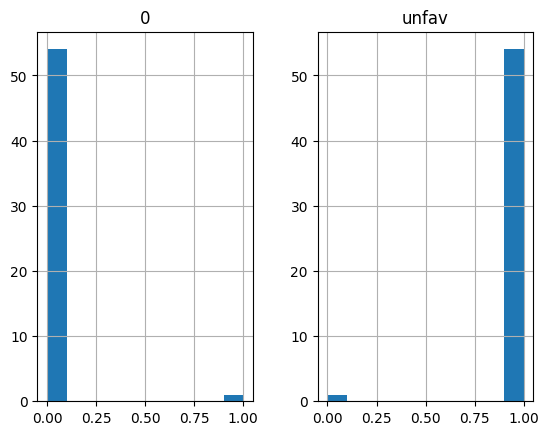

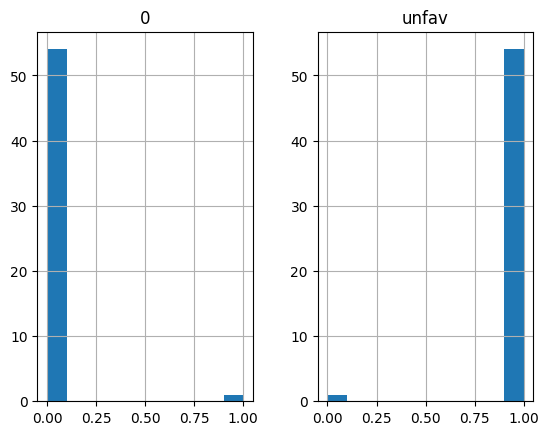

In [451]:
hmm_state_series_long_short, p_of_states_fav_unfav_long_short = generate_hmm_states(hmm, test, f_test)
hmm_state_series_long_only, p_of_states_fav_unfav_long_only = generate_hmm_states(hmm, test, f_test)
p_of_states_fav_unfav_long_short.hist()
p_of_states_fav_unfav_long_only.hist()

## Generate trading signals

In [452]:
def transact_at_open(test, hmm_state_series, p_of_states_fav_unfav):
    """
    Creates trading signals based on HMM states and calculates strategy returns.
    
    Parameters:
    -----------
    test : pd.DataFrame
        Must include columns: 'Open'
    hmm_state_series : pd.DataFrame
        Must include columns: 'hidden_state', 'state' where state is one of:
        'Long' (1), 'Short' (-1), or 'Flat' (0)
    p_of_states_fav_unfav : pd.DataFrame
        Contains state probabilities (not used in signal generation but kept for analysis)
    
    Returns:
    --------
    pd.DataFrame
        Copy of test DataFrame with additional columns:
        - 'raw_position'      : position from HMM state (-1, 0, or 1)
        - 'signal'           : trading signal (raw_position shifted by 1)
        - 'next_open'        : next day's open price
        - 'open_return'      : return from today's open to next day's open
        - 'strategy_return'  : product of signal and open_return
        - 'trade'           : indicator (1/0) if trade occurred
        - 'cum_strategy_return' and 'cum_buy_hold_return': cumulative returns
    """

    
    # Start with a copy of the test DataFrame
    df = test.copy()
    
    # Ensure index alignment
    p_of_states_fav_unfav.index = test.index
    
    # Join the HMM state information
    df = df.join(hmm_state_series[['hidden_state', 'state']])
    df = df.join(p_of_states_fav_unfav['unfav'])
    
    # Convert state to position (-1, 0, 1)
    df['raw_position'] = df['state'].map({'Long': 1.0, 'Short': -1.0, 'Flat': 0.0})
    
    # Shift the raw position once to simulate trading at the next day's open
    df['signal'] = df['raw_position'].shift(1)
    
    # Calculate returns
    df['next_open'] = df['Open'].shift(-1)
    df['open_return'] = (df['next_open'] / df['Open']) - 1
    df['open_return'] = df['open_return'].fillna(0)
    df['strategy_return'] = df['signal'] * df['open_return']
    
    # Mark trades
    df['trade'] = (df['signal'] != df['signal'].shift(1)).astype(int)
    
    # Calculate cumulative returns
    df['cum_strategy_return'] = (1 + df['strategy_return']).cumprod() - 1
    df['cum_buy_hold_return'] = (1 + df['open_return']).cumprod() - 1
    
    df['state'].hist()

    return df

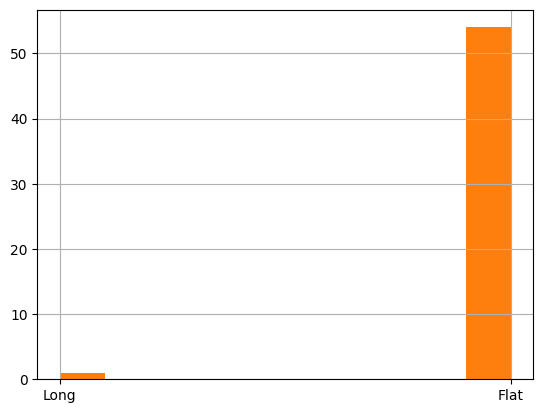

In [453]:
long_short = transact_at_open(test, hmm_state_series_long_short, p_of_states_fav_unfav_long_short)
long_only = transact_at_open(test, hmm_state_series_long_only, p_of_states_fav_unfav_long_only)


### Plot strategy results

In [454]:
def plot_hmm_results(df):
    """
    Given a DataFrame (such as that returned by transact_at_open())
    that includes:
      - Date (as a column)
      - 'hidden_state': the raw state from the HMM (e.g. 0, 1, or 2)
      - 'cum_buy_hold_return': cumulative return from buying and holding the asset
      - 'cum_strategy_return': cumulative return from the HMM-based strategy
      - 'unfav': the probability that the state is unfavored
    this function produces a multi-panel Plotly plot with backtest metrics.
    """
    # If "Date" exists in the index, then:
    if "Date" in df.index.names:
        # If "Date" already exists as a column, drop the index without adding it as a column.
        if "Date" in df.columns:
            df = df.reset_index(drop=True)
        else:
            df = df.reset_index()
    # Ensure Date is stored as datetime in the "Date" column.
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date")
    
    # Calculate backtest metrics with an inner helper function.
    def calculate_metrics(returns, cum_returns, is_strategy=True, df=None):
        total_return = cum_returns.iloc[-1]
        days = (df["Date"].iloc[-1] - df["Date"].iloc[0]).days
        ann_return = ((1 + total_return) ** (365 / days)) - 1
        
        if is_strategy:
            state_changes = df["raw_position"].diff().fillna(0)
            trades = (state_changes != 0).sum()
            active_returns = returns[df["raw_position"] != 0]
            win_rate = (active_returns > 0).sum() / len(active_returns) if len(active_returns) > 0 else 0
        else:
            trades = 0
            win_rate = 0

        wealth_index = 1 + cum_returns
        previous_peaks = wealth_index.expanding(min_periods=1).max()
        drawdowns = (wealth_index - previous_peaks) / previous_peaks
        max_drawdown = drawdowns.min()
    
        risk_free_rate = 0.02
        daily_rf = (1 + risk_free_rate) ** (1 / 365) - 1
        excess_returns = returns - daily_rf
        sharpe = np.sqrt(365) * (excess_returns.mean() / returns.std())
        
        return {
            "Total Return": f"{total_return:.2%}",
            "Annualized Return": f"{ann_return:.2%}",
            "Number of Trades": trades,
            "Max Drawdown": f"{max_drawdown:.2%}",
            "Sharpe Ratio": f"{sharpe:.2f}",
            "Win Rate": f"{win_rate:.2%}"
        }
    
    # Calculate metrics for both the strategy and buy & hold.
    strategy_metrics = calculate_metrics(
        df["strategy_return"],
        df["cum_strategy_return"],
        is_strategy=True,
        df=df
    )
    bh_metrics = calculate_metrics(
        df["open_return"],
        df["cum_buy_hold_return"],
        is_strategy=False,
        df=df
    )
    
    metrics_table = pd.DataFrame({
        "Strategy": strategy_metrics,
        "Buy & Hold": bh_metrics
    }).round(4)
    
    # Create figure (using Plotly's make_subplots) with returns, a metrics table, and unfavored probability.
    fig = make_subplots(
        rows=3, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.1,
        row_heights=[0.5, 0.2, 0.3],
        specs=[[{"type": "scatter"}],
               [{"type": "table"}],
               [{"type": "scatter"}]]
    )
    
    fig.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df["cum_buy_hold_return"],
            mode="markers",
            name="Buy & Hold",
            marker=dict(
                size=3,
                color=df["hidden_state"],
                colorscale="Viridis",
                showscale=True,
                colorbar=dict(title="Hidden State")
            )
        ),
        row=1,
        col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df["cum_strategy_return"],
            mode="lines",
            name="HMM Strategy",
            line=dict(color="red", width=2)
        ),
        row=1,
        col=1
    )
    
    fig.add_trace(
        go.Table(
            header=dict(
                values=["Metric", "Strategy", "Buy & Hold"],
                font=dict(size=12),
                align="left"
            ),
            cells=dict(
                values=[metrics_table.index, 
                        metrics_table["Strategy"],
                        metrics_table["Buy & Hold"]],
                font=dict(size=11),
                align="left"
            )
        ),
        row=2,
        col=1
    )
    
    fig.add_trace(
        go.Scatter(
            x=df["Date"],
            y=df["unfav"],
            mode="lines",
            name="Unfavored Probability",
            line=dict(color="black", width=2)
        ),
        row=3,
        col=1
    )
    
    fig.update_layout(
        title="HMM-Regime Based Strategy Analysis",
        template="plotly_white",
        height=1000,
        showlegend=True,
        legend=dict(
            yanchor="top",
            y=0.99,
            xanchor="left",
            x=0.01
        )
    )
    
    fig.update_yaxes(title_text="Cumulative Return", row=1, col=1)
    fig.update_yaxes(title_text="Unfavored Probability", row=3, col=1)
    fig.update_xaxes(title_text="Date", row=3, col=1)
    
    fig.show()

In [455]:
plot_hmm_results(long_only)
plot_hmm_results(long_short)